# DATA 266 Lab 1, Task 3: CycleGAN, Monet <-> Photo

Training was run with `python src/cyclegan.py --config src/config.yaml --data_dir ../data --out_dir .` and evaluation with `python src/evaluate_local.py` (raw logs in `logs/`). This notebook loads the trained generators and shows the data, the model, training behaviour, translations in both directions, a cycle-consistency check, and all metrics.

Domain A = Monet paintings, domain B = photos. `G_AB`: Monet -> photo, `G_BA`: photo -> Monet (the Kaggle direction).

In [1]:
import os, sys, json
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "src":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
DATA = ROOT.parent / "data"

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Image as ShowImage, display
import cyclegan

device = "cuda" if torch.cuda.is_available() else "cpu"
print("member folder:", ROOT.name)
print("torch", torch.__version__, "| device:", torch.cuda.get_device_name(0) if device == "cuda" else "CPU")

member folder: akhilesh
torch 2.11.0+cu128 | device: NVIDIA GeForce RTX 5090


## 3.1 Data: two unpaired domains

Monet paintings (domain A): 300
photos (domain B): 7038
image size: (256, 256) RGB


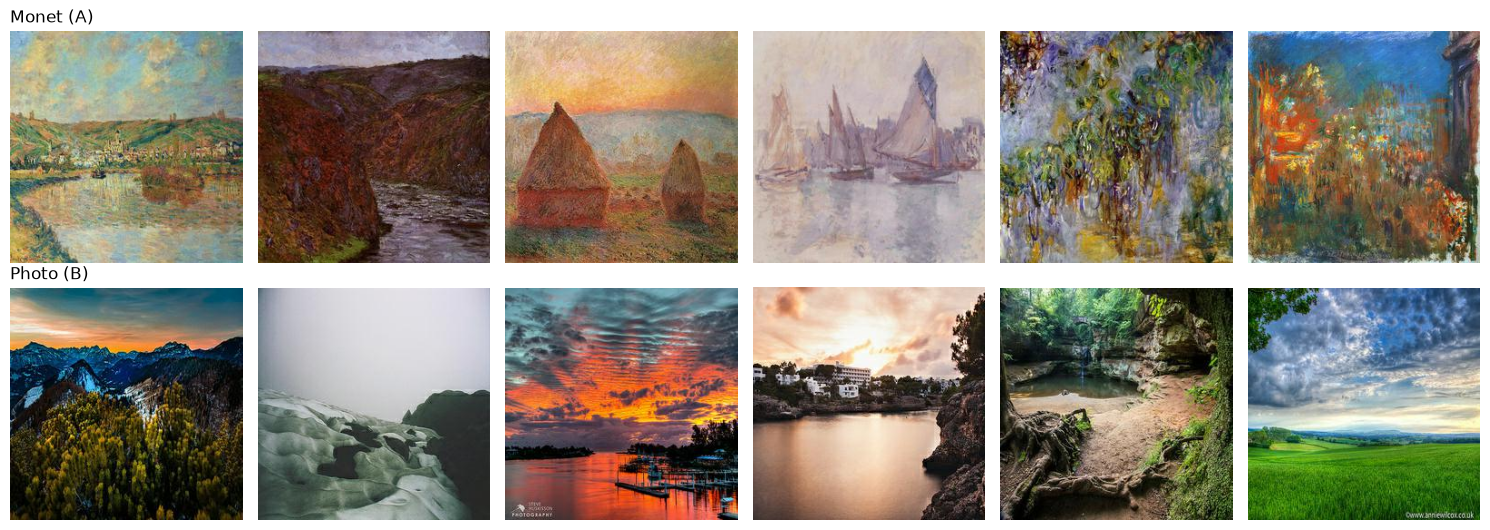

In [2]:
monet = cyclegan.list_images(DATA / "monet_jpg")
photo = cyclegan.list_images(DATA / "photo_jpg")
print("Monet paintings (domain A):", len(monet))
print("photos (domain B):", len(photo))
print("image size:", Image.open(monet[0]).size, Image.open(monet[0]).mode)

fig, ax = plt.subplots(2, 6, figsize=(15, 5.4))
rng = np.random.default_rng(0)
for j, i in enumerate(rng.choice(len(monet), 6, replace=False)):
    ax[0, j].imshow(Image.open(monet[i])); ax[0, j].axis("off")
for j, i in enumerate(rng.choice(len(photo), 6, replace=False)):
    ax[1, j].imshow(Image.open(photo[i])); ax[1, j].axis("off")
ax[0, 0].set_title("Monet (A)", loc="left"); ax[1, 0].set_title("Photo (B)", loc="left")
plt.tight_layout(); plt.show()

## Model: two ResNet generators and two PatchGAN discriminators

In [3]:
ck = torch.load("checkpoints/generators_final.pt", map_location=device)
cfg = ck["args"]
G_AB = cyclegan.build_generator(cfg).to(device).eval()
G_BA = cyclegan.build_generator(cfg).to(device).eval()
G_AB.load_state_dict(ck["G_AB"]); G_BA.load_state_dict(ck["G_BA"])
D = cyclegan.build_discriminator(cfg)

keys = ["ngf", "ndf", "g_blocks", "d_layers", "upsample", "gan_loss", "lambda_cyc", "lambda_id",
        "pool_size", "lr", "beta1", "n_epochs", "n_epochs_decay", "steps_per_epoch", "batch_size", "seed"]
display(pd.DataFrame({"setting": keys, "value": [cfg[k] for k in keys]}))
print("checkpoint epoch:", ck["epoch"])
print(f"parameters per generator: {cyclegan.n_params(G_AB):,}")
print(f"parameters per discriminator: {cyclegan.n_params(D):,}")
print(f"total (2 G + 2 D): {2 * cyclegan.n_params(G_AB) + 2 * cyclegan.n_params(D):,}")
print(G_BA)

,setting,value
0,ngf,64
1,ndf,64
2,g_blocks,9
3,d_layers,3
4,upsample,resize
5,gan_loss,lsgan
6,lambda_cyc,10.0
7,lambda_id,0.3
8,pool_size,50
9,lr,0.0002


checkpoint epoch: 30
parameters per generator: 11,378,179
parameters per discriminator: 2,764,737
total (2 G + 2 D): 28,285,832
ResnetGenerator(
  (net): Sequential(
    (0): ReflectionPad2d((3, 3, 3, 3))
    (1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1))
    (2): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (8): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (9): ReLU(inplace=True)
    (10): ResBlock(
      (block): Sequential(
        (0): ReflectionPad2d((1, 1, 1, 1))
        (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
        (2): InstanceNorm2d(256, eps=1e-05, momentum=0.1, aff

## Training behaviour: losses, stability and convergence

Per-epoch means from the unedited per-step log. The cycle and identity values are the weighted terms (lambda_cyc = 10, identity weight 0.3 x 10 = 3).

In [4]:
log = pd.read_csv("logs/train_steps_cyclegan.csv")
cols = ["G_adv_AB", "G_adv_BA", "cyc_A", "cyc_B", "idt_A", "idt_B", "loss_G", "D_A", "D_B", "gnorm_G", "gnorm_D"]
per_epoch = log.groupby("epoch")[cols].mean()
per_epoch["nonfinite_steps"] = log.groupby("epoch")["nonfinite"].sum()
per_epoch.round(3)

,G_adv_AB,G_adv_BA,cyc_A,cyc_B,idt_A,idt_B,loss_G,D_A,D_B,gnorm_G,gnorm_D,nonfinite_steps
epoch,,,,,,,,,,,,
1,0.454,0.497,2.899,3.136,0.819,0.872,8.677,0.315,0.335,65.467,25.335,0
2,0.460,0.564,2.488,2.696,0.703,0.738,7.649,0.198,0.230,47.053,24.881,0
3,0.449,0.462,2.302,2.496,0.678,0.678,7.066,0.192,0.227,40.795,23.644,0
4,0.446,0.467,2.194,2.357,0.651,0.654,6.768,0.197,0.222,38.075,22.302,0
5,0.475,0.504,2.143,2.310,0.637,0.638,6.708,0.191,0.213,36.458,21.993,0
6,0.466,0.540,2.080,2.258,0.628,0.620,6.591,0.175,0.209,33.741,21.432,0
7,0.462,0.592,2.069,2.234,0.624,0.618,6.599,0.159,0.211,34.204,21.304,0
8,0.476,0.590,1.978,2.078,0.604,0.584,6.310,0.151,0.204,32.473,20.365,0
9,0.485,0.615,2.057,2.193,0.627,0.619,6.595,0.141,0.198,34.658,19.982,0


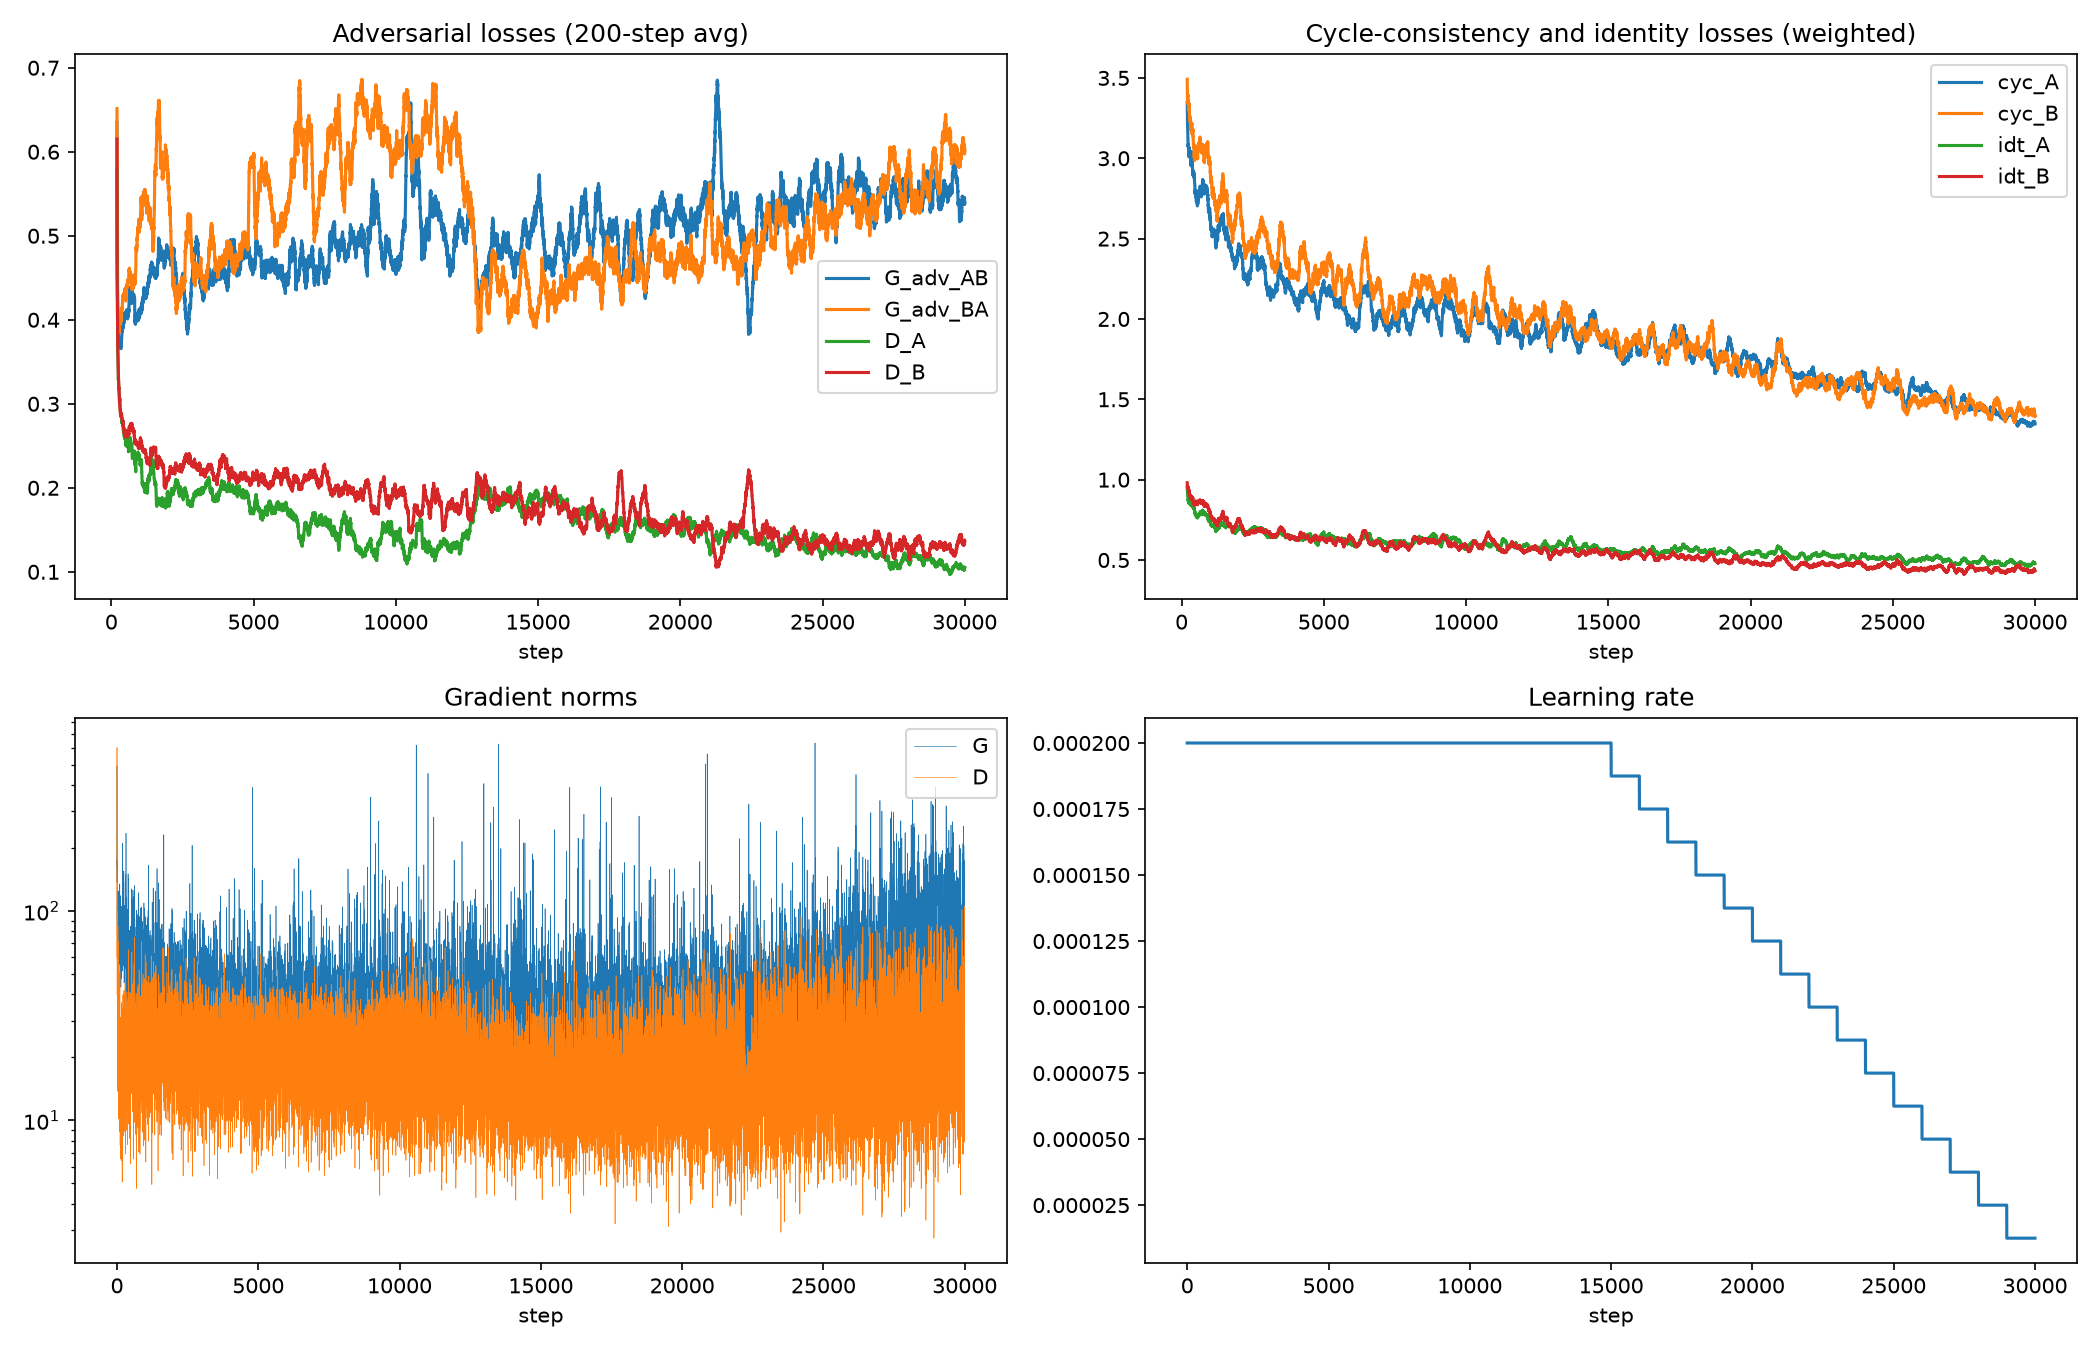

total steps: 30000 | non-finite steps: 0
generator grad norm: mean 40.0, 99th pct 135.8, max 634.2
discriminator grad norm: mean 19.6, 99th pct 51.9, max 604.1


In [5]:
display(ShowImage("outputs/loss_curves.png"))
print("total steps:", len(log), "| non-finite steps:", int(log["nonfinite"].sum()))
print("generator grad norm: mean %.1f, 99th pct %.1f, max %.1f" % (log.gnorm_G.mean(), log.gnorm_G.quantile(0.99), log.gnorm_G.max()))
print("discriminator grad norm: mean %.1f, 99th pct %.1f, max %.1f" % (log.gnorm_D.mean(), log.gnorm_D.quantile(0.99), log.gnorm_D.max()))

### Sample grids saved during training

Rows: Monet, Monet -> photo, reconstructed Monet, photo, photo -> Monet, reconstructed photo.

epoch_001


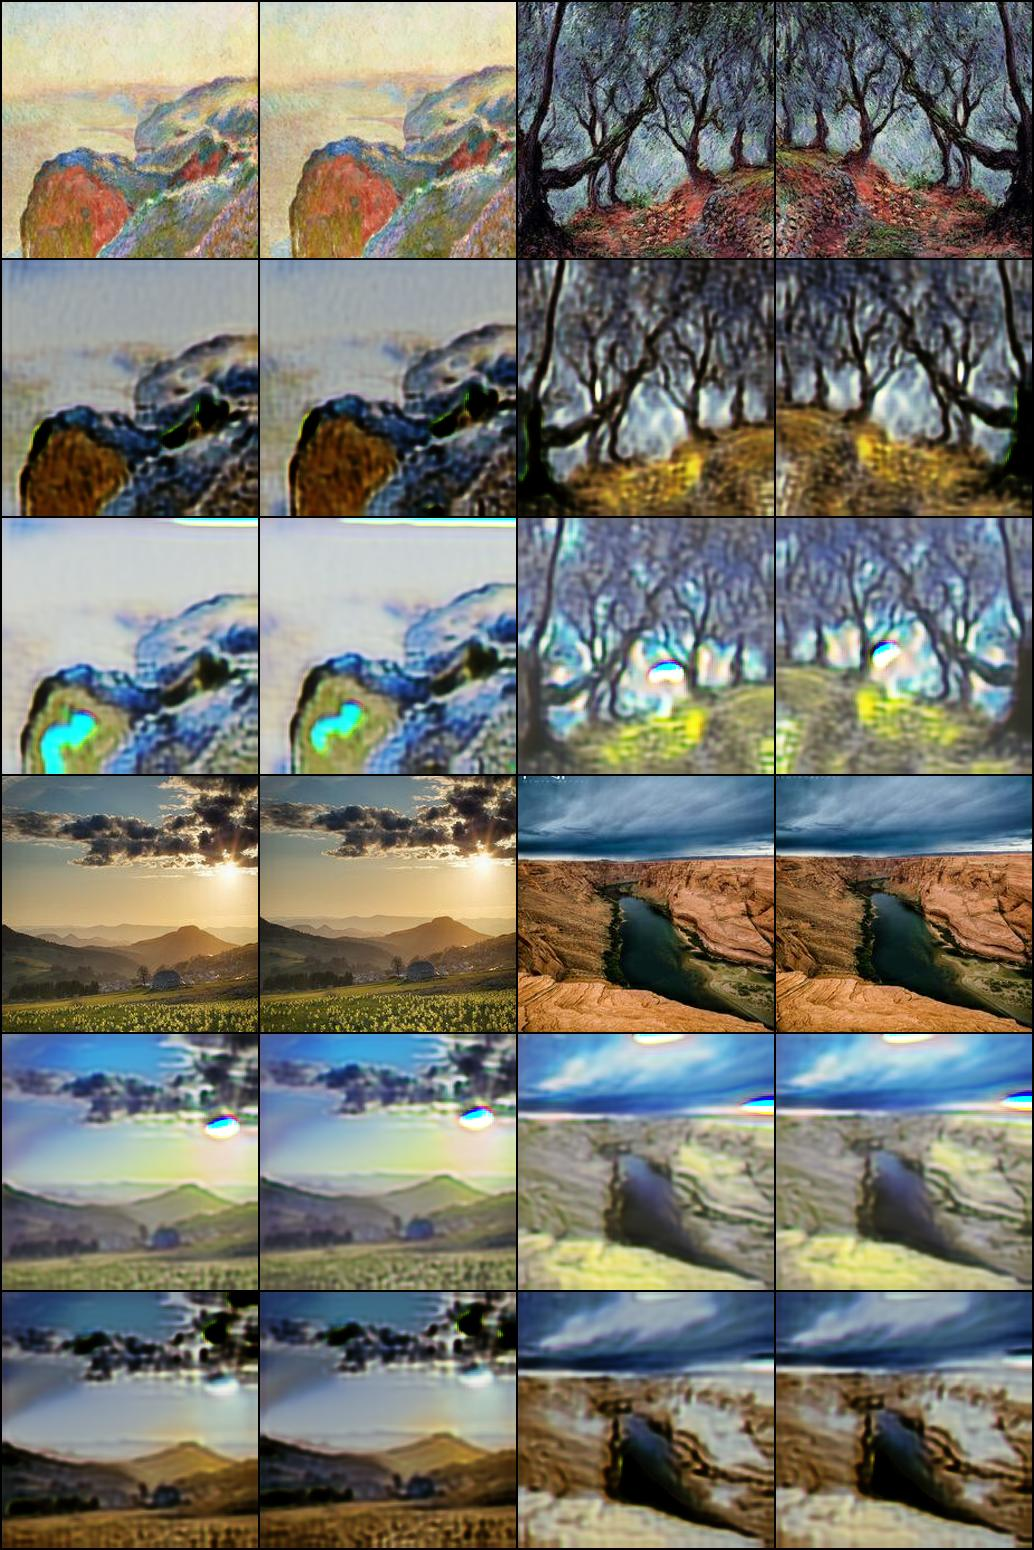

epoch_005


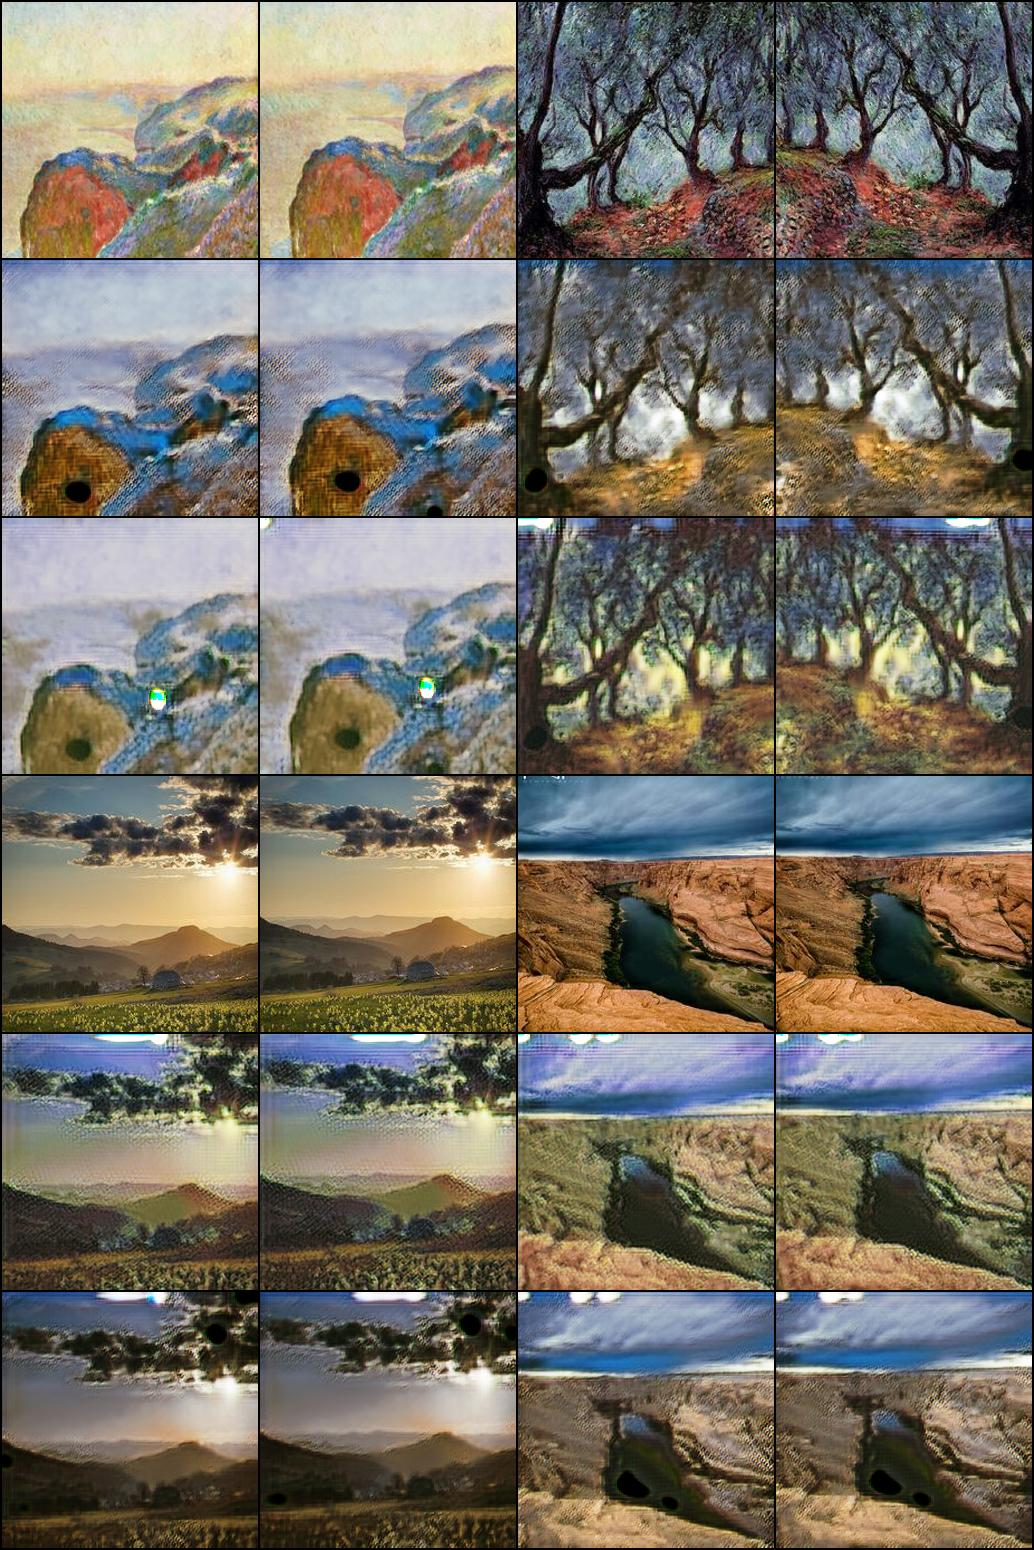

epoch_015


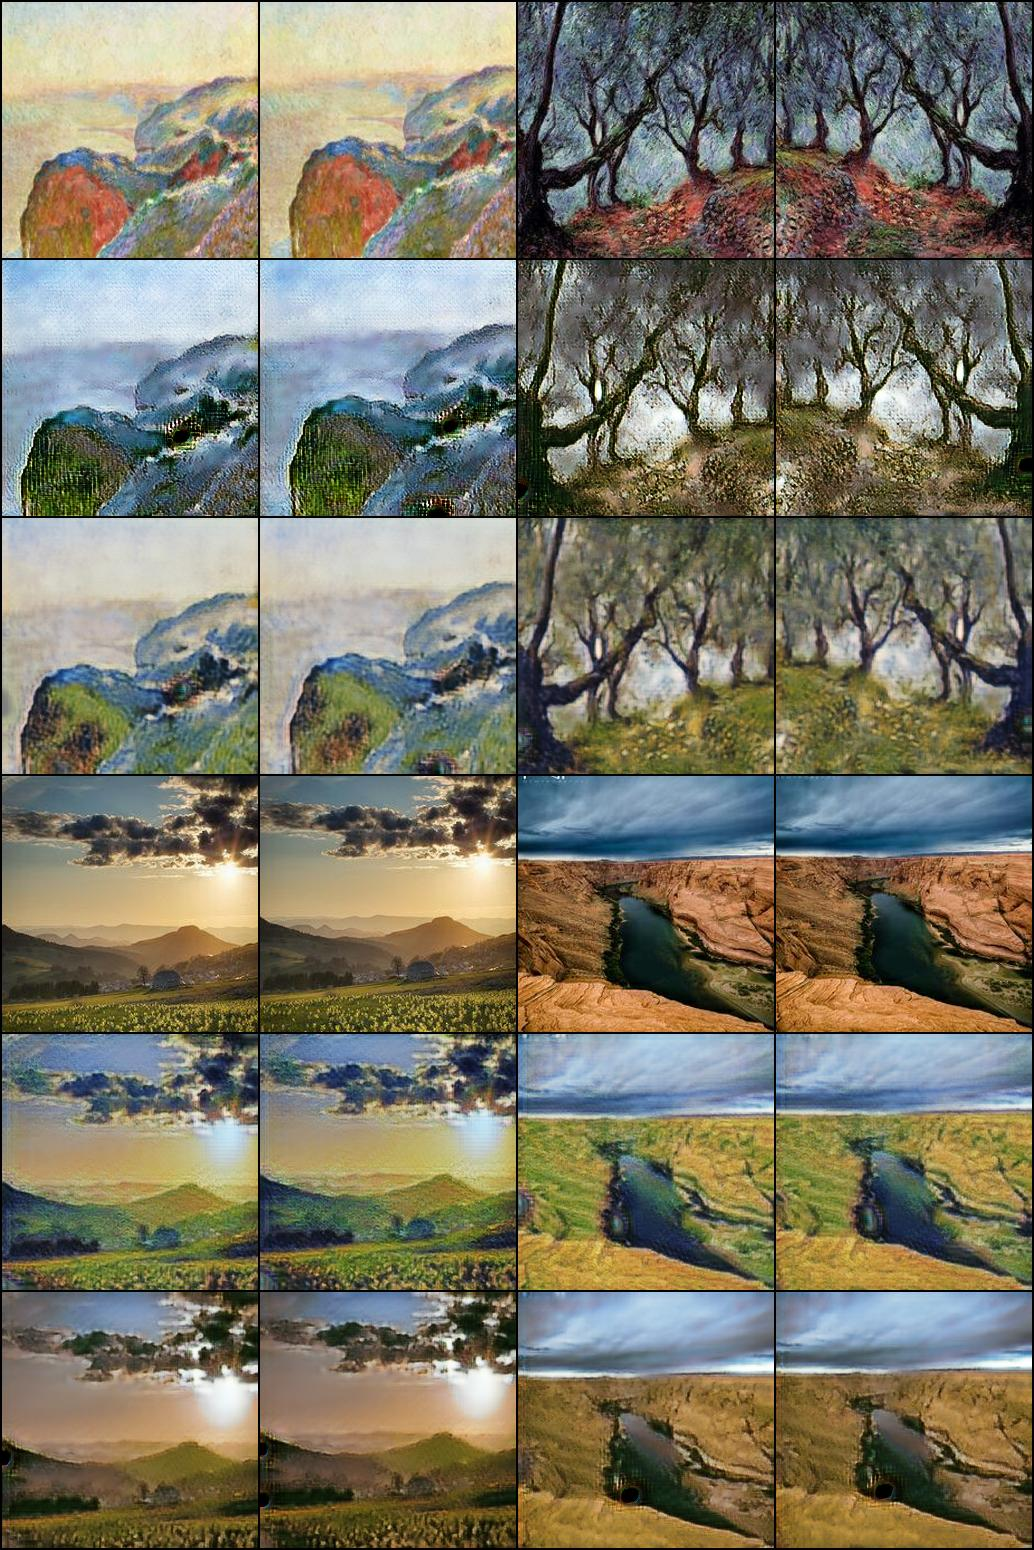

epoch_030


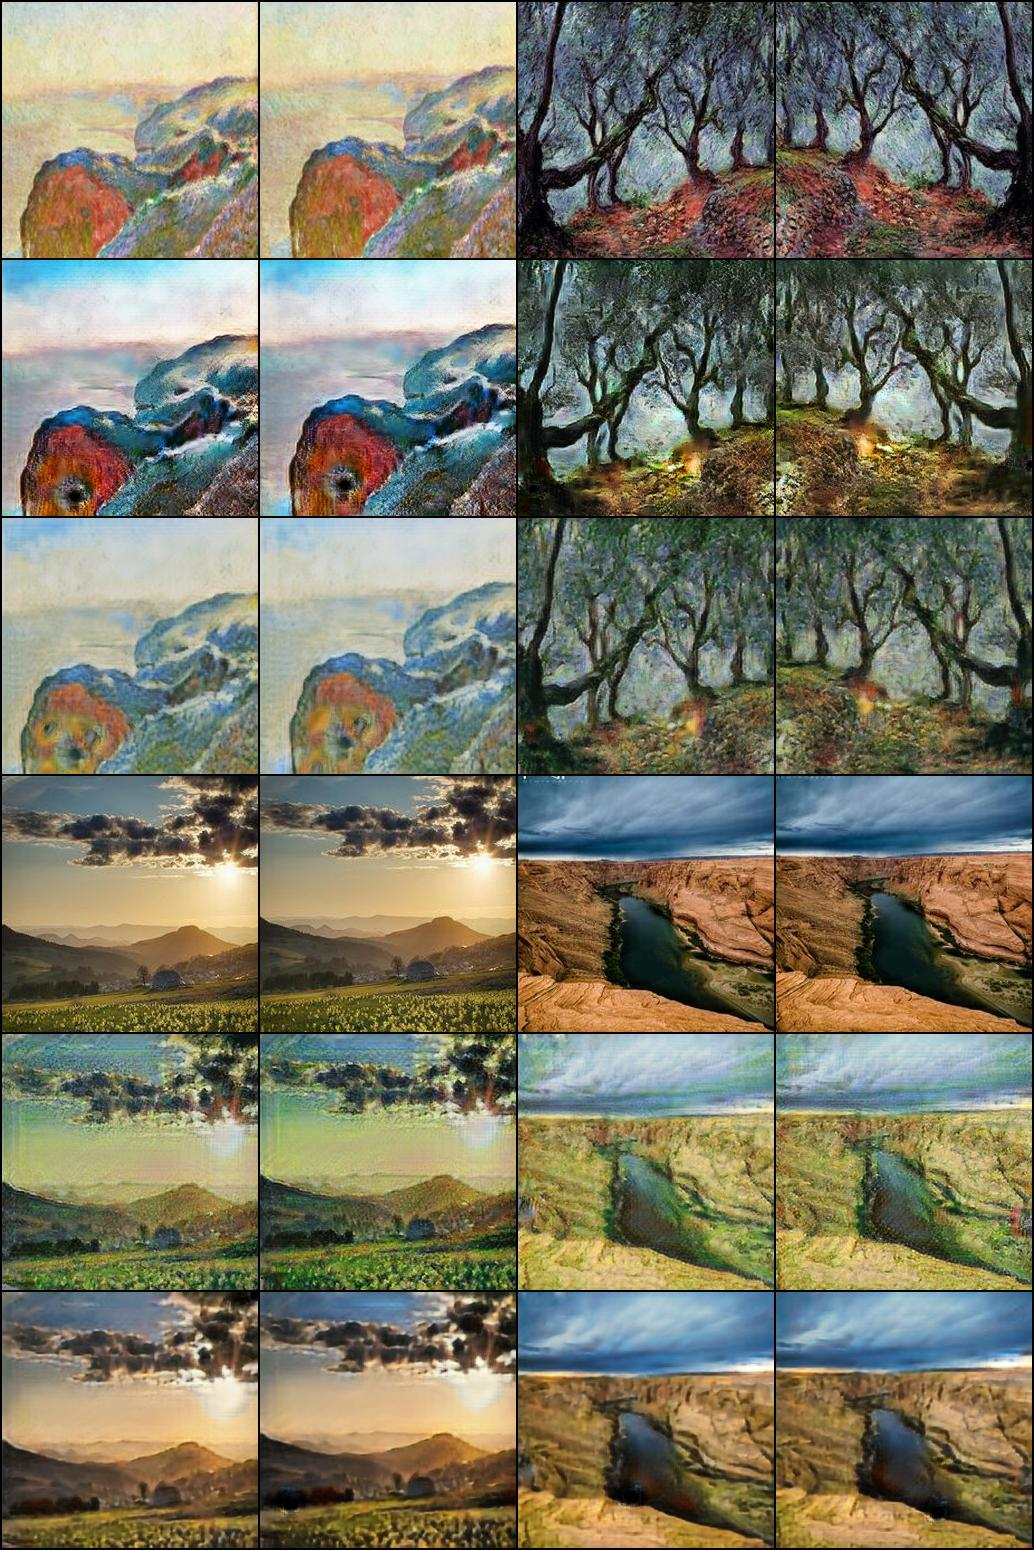

In [6]:
samples = sorted((ROOT / "outputs" / "train_samples").glob("epoch_*.jpg"))
pick = [s for s in samples if s.stem in ("epoch_001", "epoch_005", "epoch_015", "epoch_030")] or samples[-1:]
for s in pick:
    print(s.stem)
    display(ShowImage(str(s), width=520))

## Translations with the final generators

Each row: input, translation, and the reconstruction after translating back (the cycle).

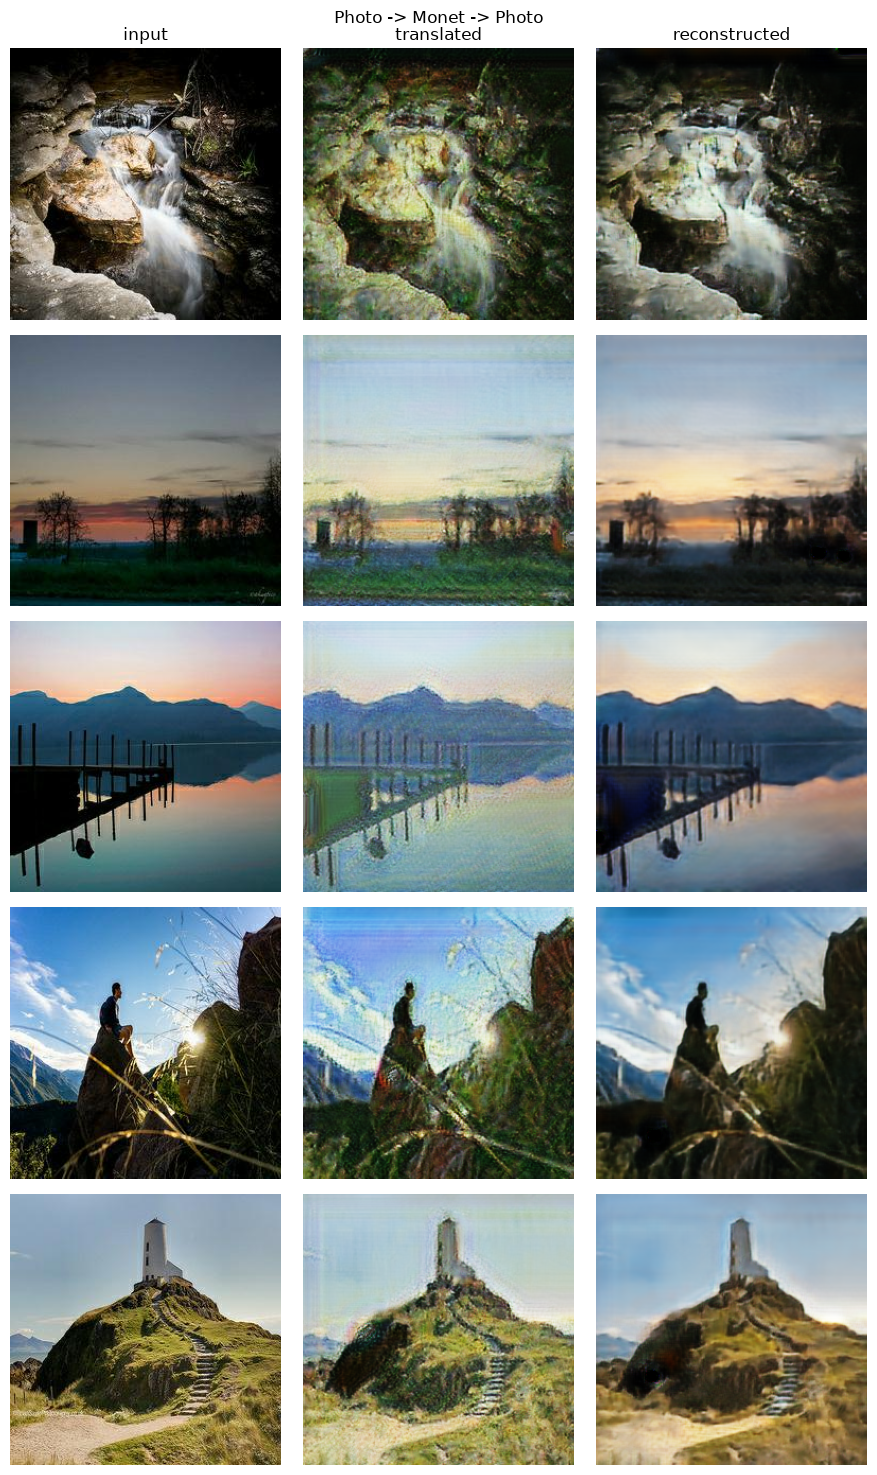

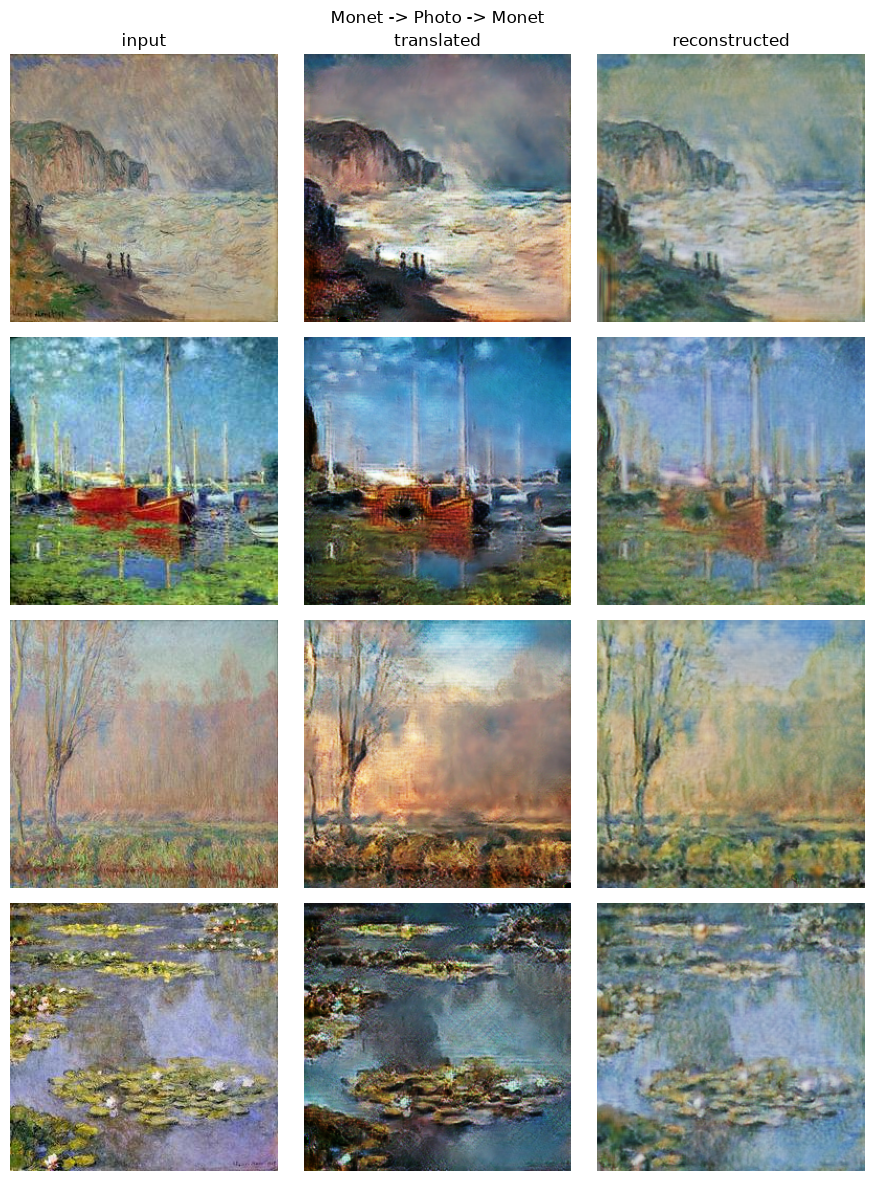

In [7]:
import torchvision.transforms as T
tf = T.Compose([T.Resize((256, 256)), T.ToTensor(), T.Normalize([0.5] * 3, [0.5] * 3)])
to_img = lambda t: (t.clamp(-1, 1) * 0.5 + 0.5).permute(1, 2, 0).cpu().numpy()

def show_cycle(files, G, G_back, title):
    x = torch.stack([tf(Image.open(f).convert("RGB")) for f in files]).to(device)
    with torch.no_grad():
        y = G(x); r = G_back(y)
    fig, ax = plt.subplots(len(files), 3, figsize=(9, 3 * len(files)))
    for i in range(len(files)):
        for j, (img, name) in enumerate(((x[i], "input"), (y[i], "translated"), (r[i], "reconstructed"))):
            ax[i, j].imshow(to_img(img)); ax[i, j].axis("off")
            if i == 0: ax[i, j].set_title(name)
    fig.suptitle(title); plt.tight_layout(); plt.show()

rng = np.random.default_rng(266)
show_cycle([photo[i] for i in rng.choice(len(photo), 5, replace=False)], G_BA, G_AB, "Photo -> Monet -> Photo")
show_cycle([monet[i] for i in rng.choice(len(monet), 4, replace=False)], G_AB, G_BA, "Monet -> Photo -> Monet")

## 3.2 Verifying cycle-consistency

If the cycle constraint works, translating an image and back should return something much closer to the original than the translation itself is. Identity: a generator given an image already in its output domain should change it only a little.

In [8]:
@torch.no_grad()
def l1_stats(files, G, G_back, n=200, bs=25):
    files = files[:n]; trans, cyc, idt = [], [], []
    for i in range(0, len(files), bs):
        x = torch.stack([tf(Image.open(f).convert("RGB")) for f in files[i:i + bs]]).to(device)
        y = G(x); r = G_back(y)
        trans += (y - x).abs().mean((1, 2, 3)).tolist()
        cyc += (r - x).abs().mean((1, 2, 3)).tolist()
        idt += (G_back(x) - x).abs().mean((1, 2, 3)).tolist()
    return np.mean(trans), np.mean(cyc), np.mean(idt)

rows = []
for name, files, G, Gb in (("photo -> Monet -> photo", photo, G_BA, G_AB), ("Monet -> photo -> Monet", monet, G_AB, G_BA)):
    t, c, i = l1_stats(files, G, Gb)
    rows.append({"cycle": name, "L1(input, translation)": t, "L1(input, reconstruction)": c,
                 "identity L1 (input through the other generator)": i})
pd.DataFrame(rows).round(4)

,cycle,"L1(input, translation)","L1(input, reconstruction)",identity L1 (input through the other generator)
0,photo -> Monet -> photo,0.2182,0.1438,0.1417
1,Monet -> photo -> Monet,0.2091,0.1411,0.1611


## Metrics (both directions)

Computed by `src/evaluate_local.py` on all 7,038 photos -> Monet and all 300 Monet -> photo, with torchvision's Inception-v3 features. That extractor reproduces the competition's `real_stats.npz` (FID 0.074 between the real Monet images and the provided statistics), so the FID is on the same scale as Kaggle's.

In [9]:
pd.set_option("display.max_rows", 80)
pd.read_csv("full_metrics_report.csv")

,metric,direction,value
0,FID,B2A (photo->monet),93.5393
1,FID_vs_real_stats_npz[mu_real/sigma_real],B2A (photo->monet),93.5641
2,MiFID_cosine_paired_vs_npz_feats,B2A (photo->monet),0.410384
3,KID_mean,B2A (photo->monet),0.0167695
4,KID_std,B2A (photo->monet),0.00105047
5,precision,B2A (photo->monet),0.338875
6,recall,B2A (photo->monet),0.51
7,density,B2A (photo->monet),0.285687
8,coverage,B2A (photo->monet),0.906667
9,MiFID_cosine_paired,B2A (photo->monet),0.410397


## Kaggle submission

Score = mean of FID and MiFID. Public leaderboard: 46.9872 (shown by Kaggle as -46.9872), rank 2 at the time of submission.

In [10]:
print(open("submission.csv").read())

ID,FID,MiFID
1,93.564110,0.410384



## Human audit

30 fixed photo -> Monet samples (seed 266, the same inputs for every team member), shown blinded as input | output pairs in `outputs/audit/`. Two raters scored style, content preservation and artifacts from 1 to 5.

In [11]:
m = pd.read_csv("full_metrics_report.csv")
audit = m[m.metric.str.startswith("human_audit")]
if len(audit):
    display(audit)
else:
    print("Human audit not computed yet: fill outputs/audit/ratings_rater1.csv and ratings_rater2.csv, then run")
    print("python src/evaluate_local.py --mode audit_kappa --out_dir . --rater1 outputs/audit/ratings_rater1.csv --rater2 outputs/audit/ratings_rater2.csv")

Human audit not computed yet: fill outputs/audit/ratings_rater1.csv and ratings_rater2.csv, then run
python src/evaluate_local.py --mode audit_kappa --out_dir . --rater1 outputs/audit/ratings_rater1.csv --rater2 outputs/audit/ratings_rater2.csv
